1.6.4


C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_han

Month
1950-01-01    5.10
1950-02-01    5.69
1950-03-01    7.71
1950-04-01    9.37
1950-05-01    8.14
              ... 
2023-08-01    5.29
2023-09-01    4.89
2023-10-01    6.45
2023-11-01    7.78
2023-12-01    7.16
Length: 888, dtype: float64


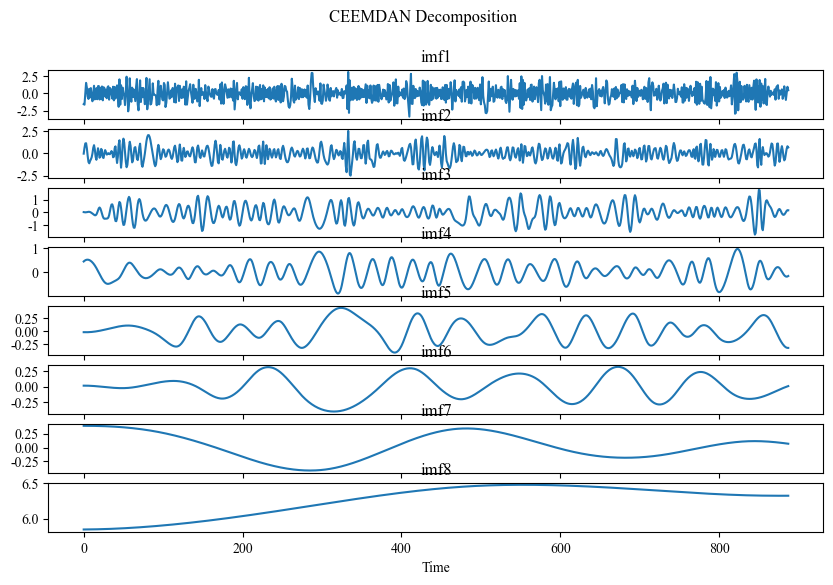

         imf1      imf2      imf3      imf4      imf5      imf6      imf7  \
0   -1.559233 -0.032201  0.014577  0.442961 -0.018431  0.013428  0.390751   
1   -1.640510  0.624269  0.001128  0.471539 -0.018925  0.013484  0.390780   
2   -0.120305  1.108100 -0.004771  0.493621 -0.019223  0.013457  0.390790   
3    1.486998  1.142634 -0.001625  0.508747 -0.019318  0.013344  0.390781   
4    0.812455  0.567066  0.010205  0.517025 -0.019206  0.013145  0.390753   
..        ...       ...       ...       ...       ...       ...       ...   
883  0.073541 -0.606404 -0.096125 -0.164094 -0.300537 -0.011994  0.076258   
884 -0.956853 -0.055559  0.011314 -0.183848 -0.311690 -0.007158  0.074398   
885 -0.045641  0.505176  0.110851 -0.190524 -0.319340 -0.002472  0.072507   
886  0.927295  0.799151  0.168421 -0.183697 -0.323301  0.002051  0.070584   
887  0.430780  0.662595  0.158795 -0.163072 -0.323688  0.006402  0.068631   

         imf8  
0    5.848148  
1    5.848235  
2    5.848332  
3    5.8484

In [1]:
# CEEMDAN分解脚本 - 保持原样
# pip install EMD-signal
import PyEMD

print(PyEMD.__version__)
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings

# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False
df_raw_data = pd.read_csv('Japan-DroughtPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 cdd（推荐做法），构造与模板一致的 Series 写法
series_close = pd.Series(
    df_raw_data['cdd'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['cdd'].values提取'cdd'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)


def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i + 1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。


df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-JAPAN-CDD1.xlsx", index=False)
#保存数据为CEEMDAN-JAPAN-CDD.xlsx